## Cell 0 — Setup + input check

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXP_DIR = Path.cwd()
if str(EXP_DIR) not in sys.path:
    sys.path.insert(0, str(EXP_DIR))
import nli_lib as lib

lib.OUT_DIR.mkdir(exist_ok=True)
lib.TABLES_DIR.mkdir(exist_ok=True)
lib.STATS_DIR.mkdir(exist_ok=True)
lib.FIGURES_DIR.mkdir(exist_ok=True)

REQUIRED = [
    'adjudicated_v1.csv', 'adjudicated_v2.csv', 'adjudicated_v3.csv',
    'human_review_completed.csv', 'disagreements.csv',
    'pre_fix/pairing_pre_topic_fix.csv',
]
missing = [f for f in REQUIRED if not (lib.DATA_DIR / f).exists()]
if missing:
    raise FileNotFoundError(f'Missing inputs: {missing}')
print('[OK] All required inputs present')

[OK] All required inputs present


## Cell 1 — Load arbiter v1/v2/v3 + human review (n=120)

In [ ]:
human = pd.read_csv(lib.DATA_DIR / "human_review_completed.csv", low_memory=False)
adj_v1 = pd.read_csv(lib.DATA_DIR / "adjudicated_v1.csv", low_memory=False)
adj_v2 = pd.read_csv(lib.DATA_DIR / "adjudicated_v2.csv", low_memory=False)
adj_v3 = pd.read_csv(lib.DATA_DIR / "adjudicated_v3.csv", low_memory=False)

print(f'human review v1: {human.shape}  (n_human={len(human)})')
print(f'adjudicated v1:  {adj_v1.shape}  (n_disagreement={len(adj_v1)})')
print(f'adjudicated v2:  {adj_v2.shape}')
print(f'adjudicated v3:  {adj_v3.shape}  non-null verdicts: {adj_v3["correct_status"].notna().sum()}')

h_marg = human['human_correct_status'].str.strip().str.lower().value_counts()
print('\nHuman marginals (n=120):')
for s in ['pass', 'partial', 'no_evidence']:
    n = int(h_marg.get(s, 0))
    print(f'  {s:14s} {n:3d}  ({n/len(human)*100:.1f}%)')

human review v1: (120, 12)  (n_human=120)
adjudicated v1:  (2361, 19)  (n_disagreement=2361)
adjudicated v2:  (2361, 19)
adjudicated v3:  (2361, 19)  non-null verdicts: 2361

Human marginals (n=120):
  pass            38  (31.7%)
  partial         48  (40.0%)
  no_evidence     34  (28.3%)


## Cell 2 — §5.4.1 Cohen's κ panel (v1 / v2 / v3 vs human)

**Method (post-fix redo)**:

- All three arbiters now cover the SAME post-fix disagreement universe (n=2361). Human review (n=120) sampled fresh from `disagreements.csv` (Phase 3, `--seed 42`, 16 strata).
- v1 / v2 / v3 all merge with human via canonical join keys → **n=120 consistently**.
- v3 κ computed on 3-way intersection (v1 ∩ v2 ∩ v3 ∩ human non-null); with post-fix universe, 3-way ≡ 2-way.

In [3]:
kappa_panel = lib.arbiter_kappa_panel(human, adj_v1, adj_v2, adj_v3)
print('Cohen\'s κ panel:')
print(kappa_panel.to_string(index=False))

kappa_panel.to_csv(lib.TABLES_DIR / 'T_TN4_kappa_panel.csv', index=False)
print(f'\nSaved: {lib.TABLES_DIR / "T_TN4_kappa_panel.csv"}')

k_v1 = float(kappa_panel.loc[kappa_panel['arbiter'] == 'v1', 'cohen_kappa'].iloc[0])
k_v2 = float(kappa_panel.loc[kappa_panel['arbiter'] == 'v2', 'cohen_kappa'].iloc[0])
k_v3 = float(kappa_panel.loc[kappa_panel['arbiter'] == 'v3', 'cohen_kappa'].iloc[0])
print(f'\nΔκ (v2 - v1) = {k_v2 - k_v1:+.4f}')
print(f'Δκ (v3 - v2) = {k_v3 - k_v2:+.4f}', end='')
print('  <- v3 REGRESSED vs v2' if k_v3 < k_v2 else '  <- v3 improved over v2 (unexpected)')

Cohen's κ panel:
arbiter   n  agreement_rate  cohen_kappa interpretation
     v1 120          0.5500       0.2892           fair
     v2 120          0.5917       0.4108       moderate
     v3 120          0.5500       0.2833           fair

Saved: D:\Final_GRAG\experiments\module3_nli\outputs\tables\T_TN4_kappa_panel.csv

Δκ (v2 - v1) = +0.1216
Δκ (v3 - v2) = -0.1275  <- v3 REGRESSED vs v2


## Cell 3 — §5.4.2 Marginal distribution (human vs v1 vs v2) + F5 figure

Marginal status distribution:
    source   n  n_pass  n_partial  n_no_evidence  pct_pass  pct_partial  pct_no_evidence
     Human 120      38         48             34      31.7         40.0             28.3
Arbiter v1 120      14         82             24      11.7         68.3             20.0
Arbiter v2 120      50         10             60      41.7          8.3             50.0
Arbiter v3 120      15         87             18      12.5         72.5             15.0

Saved: D:\Final_GRAG\experiments\module3_nli\outputs\tables\T_TN4_marginal_distribution.csv


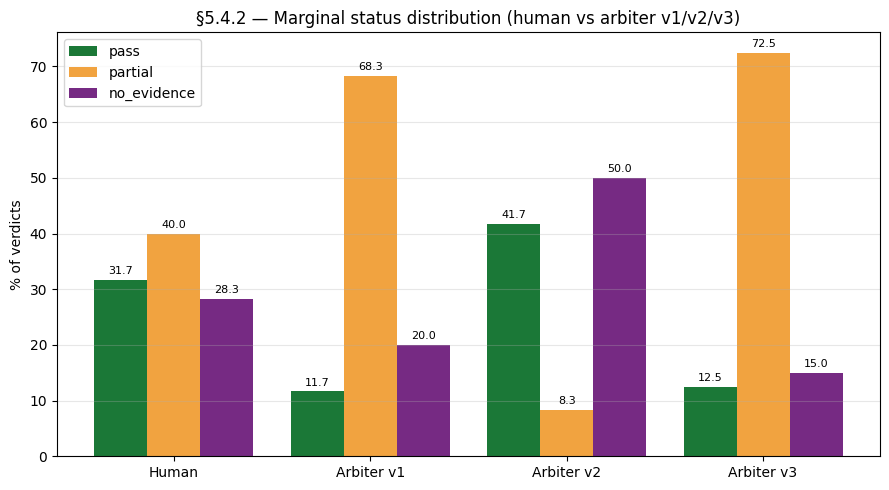

Saved: D:\Final_GRAG\experiments\module3_nli\outputs\figures\F5_arbiter_marginal.png


In [4]:
marg = lib.arbiter_marginal_distribution(human, adj_v1, adj_v2, adj_v3)
print('Marginal status distribution:')
print(marg.to_string(index=False))

marg.to_csv(lib.TABLES_DIR / 'T_TN4_marginal_distribution.csv', index=False)
print(f'\nSaved: {lib.TABLES_DIR / "T_TN4_marginal_distribution.csv"}')

fig, ax = plt.subplots(figsize=(9, 5))
sources = marg['source'].tolist()
x = np.arange(len(sources))
width = 0.27
pcts_pass    = marg['pct_pass'].values
pcts_partial = marg['pct_partial'].values
pcts_none    = marg['pct_no_evidence'].values
ax.bar(x - width, pcts_pass,    width, label='pass',        color='#1b7837')
ax.bar(x,         pcts_partial, width, label='partial',     color='#f1a340')
ax.bar(x + width, pcts_none,    width, label='no_evidence', color='#762a83')
ax.set_xticks(x)
ax.set_xticklabels(sources)
ax.set_ylabel('% of verdicts')
ax.set_title('§5.4.2 — Marginal status distribution (human vs arbiter v1/v2/v3)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for i, pct in enumerate(pcts_pass):
    ax.text(i - width, pct + 1, f'{pct:.1f}', ha='center', fontsize=8)
for i, pct in enumerate(pcts_partial):
    ax.text(i, pct + 1, f'{pct:.1f}', ha='center', fontsize=8)
for i, pct in enumerate(pcts_none):
    ax.text(i + width, pct + 1, f'{pct:.1f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(lib.FIGURES_DIR / 'F5_arbiter_marginal.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {lib.FIGURES_DIR / "F5_arbiter_marginal.png"}')

## Cell 4 — §5.4.3 Failed v3: kappa regression + confusion

v3 relaxed `partial` từ **conjunction-of-three** (v2) sang **disjunction-of-five** rules → arbiter over-uses `partial` → κ regress dưới v2. Marginal + confusion matrix dưới đây xác nhận pattern.

In [5]:
r3 = lib.arbiter_vs_human_kappa(human, adj_v3, arbiter_label='v3')
print(f'v3 vs human (drop NaN):')
print(f'  n            : {r3["n"]}')
print(f'  agreement    : {r3["agreement_rate"]:.4f}')
print(f'  cohen κ      : {r3["cohen_kappa"]:.4f}')
print(f'  interpretation: {lib._interpret_kappa(r3["cohen_kappa"])}')

print('\nv3 marginals:')
for s in ['pass', 'partial', 'no_evidence']:
    n = int(r3['arbiter_marginals'].get(s, 0))
    print(f'  {s:14s} {n:3d}  ({n/r3["n"]*100:.1f}%)')

print('\nConfusion matrix v3 (rows=arbiter v3, cols=human):')
print(r3['confusion_matrix'].to_string())

with (lib.STATS_DIR / 'TN4_v3_failed.json').open('w', encoding='utf-8') as f:
    json.dump({
        'n': r3['n'],
        'agreement_rate': r3['agreement_rate'],
        'cohen_kappa': r3['cohen_kappa'],
        'arbiter_marginals': r3['arbiter_marginals'],
    }, f, indent=2, ensure_ascii=False)
print(f'\nSaved: {lib.STATS_DIR / "TN4_v3_failed.json"}')

v3 vs human (drop NaN):
  n            : 120
  agreement    : 0.5500
  cohen κ      : 0.2833
  interpretation: fair

v3 marginals:
  pass            15  (12.5%)
  partial         87  (72.5%)
  no_evidence     18  (15.0%)

Confusion matrix v3 (rows=arbiter v3, cols=human):
             pass  partial  no_evidence
pass           12        1            2
partial        25       42           20
no_evidence     1        5           12

Saved: D:\Final_GRAG\experiments\module3_nli\outputs\stats\TN4_v3_failed.json


## Cell 5 — §5.4.4 Sign reversal: HINT main effect E1 dưới 2 prompt arbiter

Trên cùng tập disagreement **post-fix** (n=2361), đổi arbiter prompt từ v1 (3-line definition) sang v2 (4-step decision tree với DECISIVENESS rule) → kỳ vọng E1 (V_new − A0) đảo dấu. Đây là bằng chứng prompt-sensitivity confound cho method-effect inference (lỗ hổng D — direction preserved post-fix, magnitude có thể đổi).

In [6]:
pairing_post = pd.read_csv(lib.DATA_DIR / "pairing.csv", low_memory=False)
print(f'Post-fix pairing: {pairing_post.shape}')

sr = lib.sign_reversal_e1(pairing_post, adj_v1, adj_v2)
print(f'\nSign reversal analysis (HINT main = V_new vs A0, post-fix universe):')
print(f'  n_disagreement_cases : {sr["n_disagreements"]}')
print(f'  E1 under v1 GT       : {sr["e1_v1_pp"]:+.2f} pp')
print(f'  E1 under v2 GT       : {sr["e1_v2_pp"]:+.2f} pp')
print(f'  sign reversed?       : {sr["sign_reversed"]}')
print()
if sr["sign_reversed"]:
    print('  → CONFIRMED post-fix: prompt sensitivity reverses HINT-main-effect direction')
    print('    Method-effect inference (V_new better than A0?) is confounded by arbiter prompt.')
else:
    print('  → NOT REVERSED post-fix: bug-fix absorbed the prompt confound on this universe.')

with (lib.STATS_DIR / 'TN4_sign_reversal.json').open('w', encoding='utf-8') as f:
    json.dump(sr, f, indent=2)
print(f'\nSaved: {lib.STATS_DIR / "TN4_sign_reversal.json"}')

Post-fix pairing: (8670, 39)

Sign reversal analysis (HINT main = V_new vs A0, post-fix universe):
  n_disagreement_cases : 2361
  E1 under v1 GT       : -6.31 pp
  E1 under v2 GT       : +3.64 pp
  sign reversed?       : True

  → CONFIRMED post-fix: prompt sensitivity reverses HINT-main-effect direction
    Method-effect inference (V_new better than A0?) is confounded by arbiter prompt.

Saved: D:\Final_GRAG\experiments\module3_nli\outputs\stats\TN4_sign_reversal.json


## Cell 6 — Verification summary `[PASS/FAIL]`

In [7]:
checks = []

n_v1 = int(kappa_panel.loc[kappa_panel['arbiter'] == 'v1', 'n'].iloc[0])
n_v2 = int(kappa_panel.loc[kappa_panel['arbiter'] == 'v2', 'n'].iloc[0])
n_v3 = int(kappa_panel.loc[kappa_panel['arbiter'] == 'v3', 'n'].iloc[0])

checks.append(('kappa panel: n_v1 == n_v2 == n_v3 (post-fix universe consistency)',
               n_v1 == n_v2 == n_v3, f'n_v1={n_v1}, n_v2={n_v2}, n_v3={n_v3}'))
checks.append(('kappa panel: each n within ±5 of human n=120',
               all(abs(n - 120) <= 5 for n in (n_v1, n_v2, n_v3)),
               f'expect each in [115, 125]: {n_v1}, {n_v2}, {n_v3}'))
checks.append(('all kappa values within valid range [-0.5, 1.0]',
               all(-0.5 <= k <= 1.0 for k in (k_v1, k_v2, k_v3)),
               f'v1={k_v1:.4f}, v2={k_v2:.4f}, v3={k_v3:.4f}'))
checks.append(('v2 is the highest-κ arbiter (DECISIVENESS prompt wins)',
               k_v2 == max(k_v1, k_v2, k_v3),
               f'v1={k_v1:.4f}, v2={k_v2:.4f}, v3={k_v3:.4f}'))
checks.append(('v3 regresses vs v2 (BALANCED disjunction-of-5 over-uses partial)',
               k_v3 < k_v2, f'v3={k_v3:.4f}, v2={k_v2:.4f}'))

h_pass = int(marg.loc[marg['source'] == 'Human', 'n_pass'].iloc[0])
h_part = int(marg.loc[marg['source'] == 'Human', 'n_partial'].iloc[0])
h_none = int(marg.loc[marg['source'] == 'Human', 'n_no_evidence'].iloc[0])
checks.append(('human marginals balanced (each status ≥ 10%)',
               all(c / 120 >= 0.10 for c in (h_pass, h_part, h_none)),
               f'pass={h_pass}, partial={h_part}, no_evidence={h_none}'))

v1_part = int(marg.loc[marg['source'] == 'Arbiter v1', 'n_partial'].iloc[0])
checks.append(('v1 over-uses "partial" (>50%, under-specified prompt)',
               v1_part / 120 > 0.50, f'{v1_part}/120 = {v1_part/120*100:.1f}%'))

v2_none = int(marg.loc[marg['source'] == 'Arbiter v2', 'n_no_evidence'].iloc[0])
checks.append(('v2 over-uses "no_evidence" vs human (DECISIVENESS to extremes)',
               v2_none > h_none, f'v2={v2_none} vs human={h_none}'))

v3_part = int(marg.loc[marg['source'] == 'Arbiter v3', 'n_partial'].iloc[0])
checks.append(('v3 over-uses "partial" (>60%, BALANCED disjunction-of-5)',
               v3_part / 120 > 0.60, f'{v3_part}/120 = {v3_part/120*100:.1f}%'))

checks.append(('E1 sign reversal v1 vs v2 GT (prompt sensitivity holds post-fix)',
               sr['sign_reversed'], f'v1={sr["e1_v1_pp"]:+.2f}pp / v2={sr["e1_v2_pp"]:+.2f}pp'))

print('=' * 70)
print('TN4 Verification Summary (post-fix)')
print('=' * 70)
all_pass = True
for name, ok, info in checks:
    tag = '[PASS]' if ok else '[FAIL]'
    print(f'  {tag} {name:60s}  {info}')
    if not ok:
        all_pass = False
print('=' * 70)
print(f'[{"ALL PASS" if all_pass else "FAIL"}]')
print('=' * 70)

TN4 Verification Summary (post-fix)
  [PASS] kappa panel: n_v1 == n_v2 == n_v3 (post-fix universe consistency)  n_v1=120, n_v2=120, n_v3=120
  [PASS] kappa panel: each n within ±5 of human n=120                  expect each in [115, 125]: 120, 120, 120
  [PASS] all kappa values within valid range [-0.5, 1.0]               v1=0.2892, v2=0.4108, v3=0.2833
  [PASS] v2 is the highest-κ arbiter (DECISIVENESS prompt wins)        v1=0.2892, v2=0.4108, v3=0.2833
  [PASS] v3 regresses vs v2 (BALANCED disjunction-of-5 over-uses partial)  v3=0.2833, v2=0.4108
  [PASS] human marginals balanced (each status ≥ 10%)                  pass=38, partial=48, no_evidence=34
  [PASS] v1 over-uses "partial" (>50%, under-specified prompt)         82/120 = 68.3%
  [PASS] v2 over-uses "no_evidence" vs human (DECISIVENESS to extremes)  v2=60 vs human=34
  [PASS] v3 over-uses "partial" (>60%, BALANCED disjunction-of-5)      87/120 = 72.5%
  [PASS] E1 sign reversal v1 vs v2 GT (prompt sensitivity holds post-fix)  